# 03 Drug Approvals and Clinical Trials EDA

This notebook explores drug approvals and clinical trials for the Global Healthcare & Pharma Analytics project.

The goal is to understand approval trends, therapy area concentration, sponsor activity, blockbuster potential, clinical trial success patterns, and trial risk indicators during the 2010–2025 main analysis period.

In [1]:
# Import core libraries
# Reference: 01_data_quality_check.ipynb - Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options
# Reference: 01_data_quality_check.ipynb - Step 1
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load datasets needed for this notebook
# Reference: 01_data_quality_check.ipynb - Step 3
drug_approvals = pd.read_csv("drug_approvals.csv")
clinical_trials = pd.read_csv("clinical_trials.csv")

# Convert date columns
# Reference: 01_data_quality_check.ipynb - Step 13
drug_approvals["approval_date"] = pd.to_datetime(drug_approvals["approval_date"])
clinical_trials["completion_date"] = pd.to_datetime(clinical_trials["completion_date"])

# Create main analysis period datasets: 2010–2025
# Reference: 02_financial_performance_eda.ipynb - Main analysis period definition
drug_approvals_main = drug_approvals[
    (drug_approvals["year"] >= 2010) & (drug_approvals["year"] <= 2025)
]

clinical_trials_main = clinical_trials[
    (clinical_trials["year"] >= 2010) & (clinical_trials["year"] <= 2025)
]

## Step 2: Validate Main Analysis Datasets

This step checks the shape and year range of the filtered drug approvals and clinical trials datasets.

In [2]:
dataset_check = pd.DataFrame({
    "dataset": ["drug_approvals_main", "clinical_trials_main"],
    "rows": [drug_approvals_main.shape[0], clinical_trials_main.shape[0]],
    "columns": [drug_approvals_main.shape[1], clinical_trials_main.shape[1]],
    "min_year": [drug_approvals_main["year"].min(), clinical_trials_main["year"].min()],
    "max_year": [drug_approvals_main["year"].max(), clinical_trials_main["year"].max()]
})

dataset_check

,dataset,rows,columns,min_year,max_year
0,drug_approvals_main,715,12,2010,2025
1,clinical_trials_main,595,12,2010,2025


## Step 3: Preview Approval and Trial Datasets

This step previews the filtered drug approvals and clinical trials datasets to confirm the available columns before analysis.

In [3]:
display(drug_approvals_main.head())
display(clinical_trials_main.head())

,approval_id,approval_date,year,drug_name,sponsor_company,drug_type,therapy_area,peak_sales_usd_bn_est,is_blockbuster,is_mega_blockbuster,description,is_real_headline
0,APP0062,2010-01-27,2010,Zolile-pril,Ionis,small_mol,neurology,2.09,1,0,FDA approval — neurology small_mol,0
1,APP0056,2010-02-13,2010,Ilemyr-zumab,Acadia,small_mol,neurology,0.28,0,0,FDA approval — neurology small_mol,0
2,APP0047,2010-03-09,2010,Lircor-tide,BioMarin,small_mol,gastrointestinal,0.42,0,0,FDA approval — gastrointestinal small_mol,0
3,APP0063,2010-03-12,2010,Urbxan-tinib,GSK,biologic,oncology,0.02,0,0,FDA approval — oncology biologic,0
4,APP0049,2010-04-04,2010,Ravxan-tide,Mirum,biologic,oncology,0.44,0,0,FDA approval — oncology biologic,0


,trial_id,completion_date,year,sponsor,therapy_area,phase,enrollment_n,duration_months,outcome,is_success,is_failure,estimated_stock_impact_pct
0,NCT00000024,2010-01-05,2010,BioNTech,neurology,Phase 2,186,11,Met primary endpoint,1,0,6.0
1,NCT00000015,2010-02-15,2010,Pfizer,metabolic,Phase 2,181,29,Mixed results,0,0,-0.7
2,NCT00000013,2010-02-27,2010,GSK,oncology,Phase 2,115,13,Failed primary endpoint,0,1,-33.2
3,NCT00000022,2010-03-02,2010,Takeda,infectious,Phase 2,359,15,Met primary endpoint,1,0,12.4
4,NCT00000019,2010-04-09,2010,Novo Nordisk,oncology,Phase 3,840,42,Failed primary endpoint,0,1,-14.7


## Step 4: Drug Approvals by Year

This step calculates and visualizes the number of drug approvals by year between 2010 and 2025.

,year,approval_count
0,2010,24
1,2011,32
2,2012,41
3,2013,29
4,2014,44
5,2015,48
6,2016,23
7,2017,52
8,2018,59
9,2019,50


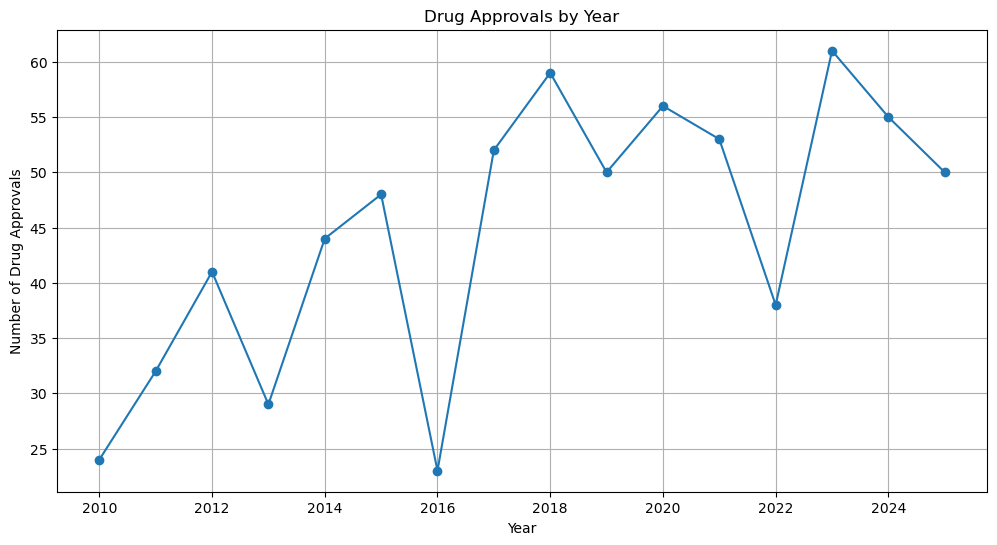

In [4]:
approvals_by_year = (
    drug_approvals_main
    .groupby("year")
    .size()
    .reset_index(name="approval_count")
)

display(approvals_by_year)

plt.figure(figsize=(12, 6))
plt.plot(
    approvals_by_year["year"],
    approvals_by_year["approval_count"],
    marker="o"
)

plt.title("Drug Approvals by Year")
plt.xlabel("Year")
plt.ylabel("Number of Drug Approvals")
plt.grid(True)
plt.show()

### Drug Approval Trend Observation

Drug approval activity fluctuated between 2010 and 2025 rather than following a perfectly linear trend.

Approval counts were relatively lower in the early 2010s and reached stronger levels in later years, with visible peaks around 2018, 2020, and 2023. This suggests that approval activity became more active over time, but remained dependent on pipeline timing, regulatory cycles, and sponsor-level development outcomes.

## Step 6: Drug Approvals by Therapy Area

This step calculates and visualizes the number of drug approvals by therapy area. It helps identify which therapeutic fields received the most approval activity between 2010 and 2025.

,therapy_area,approval_count
0,oncology,272
1,neurology,94
2,rare_disease,68
3,immunology,66
4,infectious,57
5,cardiovascular,49
6,metabolic,38
7,psychiatry,20
8,respiratory,20
9,dermatology,11


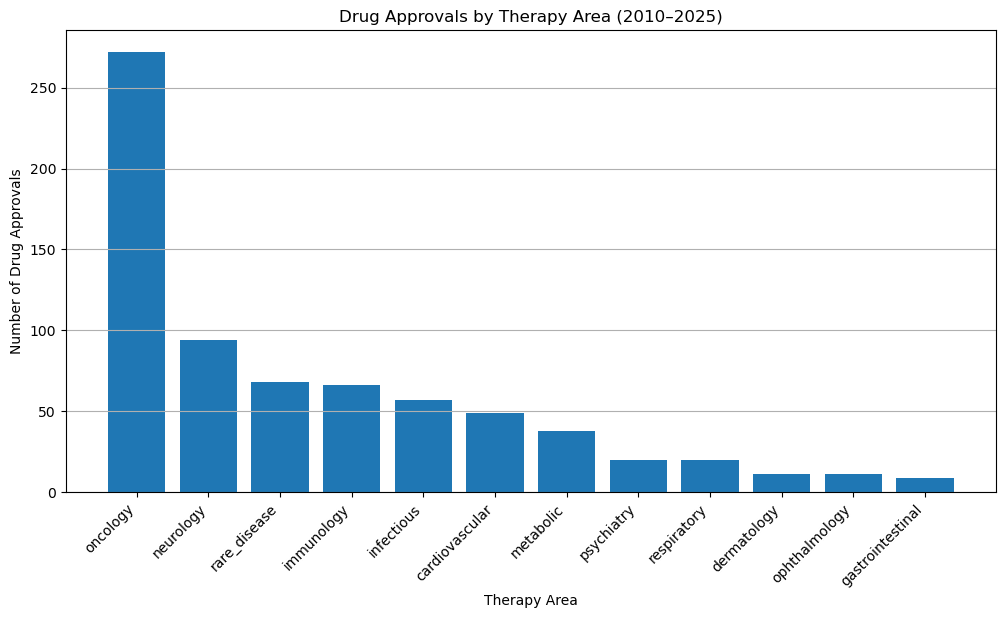

In [5]:
approvals_by_therapy_area = (
    drug_approvals_main
    .groupby("therapy_area")
    .size()
    .reset_index(name="approval_count")
    .sort_values("approval_count", ascending=False)
    .reset_index(drop=True)
)

display(approvals_by_therapy_area)

plt.figure(figsize=(12, 6))
plt.bar(
    approvals_by_therapy_area["therapy_area"],
    approvals_by_therapy_area["approval_count"]
)

plt.title("Drug Approvals by Therapy Area (2010–2025)")
plt.xlabel("Therapy Area")
plt.ylabel("Number of Drug Approvals")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Therapy Area Approval Observation

Drug approval activity was highly concentrated in oncology between 2010 and 2025.

Oncology had 272 approvals, far ahead of the second-ranked therapy area, neurology, with 94 approvals. Rare disease, immunology, infectious disease, cardiovascular, and metabolic therapies followed at lower levels.

This suggests that pharmaceutical innovation activity, at least in terms of approval count, was strongly concentrated in oncology. Later cross-dataset analysis should compare this approval concentration with disease burden to evaluate whether innovation activity aligns with real-world healthcare need.

## Step 8: Top Sponsor Companies by Drug Approvals

This step identifies the companies with the highest number of drug approvals between 2010 and 2025.

,sponsor_company,approval_count
0,Amgen,30
1,Novo Nordisk,30
2,J&J,28
3,Vertex,28
4,Novartis,27
5,Merck,26
6,AstraZeneca,26
7,Acadia,25
8,BMS,25
9,BioMarin,25


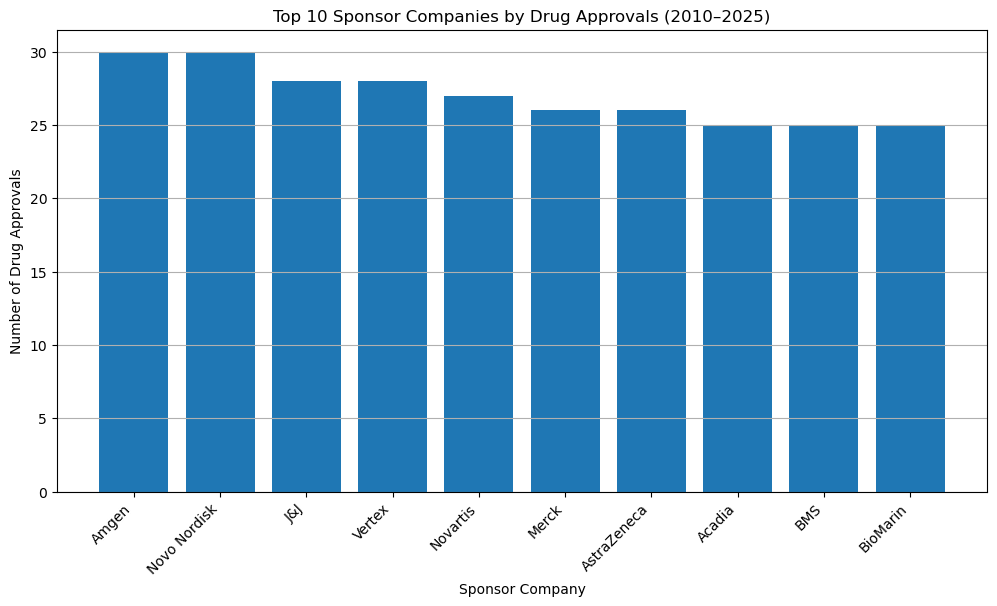

In [7]:
approvals_by_sponsor = (
    drug_approvals_main
    .groupby("sponsor_company")
    .size()
    .reset_index(name="approval_count")
    .sort_values("approval_count", ascending=False)
    .reset_index(drop=True)
)

display(approvals_by_sponsor.head(10))

top10_sponsor_approvals = approvals_by_sponsor.head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    top10_sponsor_approvals["sponsor_company"],
    top10_sponsor_approvals["approval_count"]
)

plt.title("Top 10 Sponsor Companies by Drug Approvals (2010–2025)")
plt.xlabel("Sponsor Company")
plt.ylabel("Number of Drug Approvals")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Sponsor Company Approval Observation

The top sponsor companies by drug approvals were relatively close to each other between 2010 and 2025.

Amgen and Novo Nordisk led the ranking with 30 approvals each, followed by J&J and Vertex with 28 approvals. Unlike the therapy area distribution, sponsor-level approval activity appears less concentrated among a single dominant company.

This suggests that approval activity was highly concentrated by therapy area, especially oncology, but more distributed across leading sponsor companies.

## Step 10: Drug Approvals by Drug Type

This step calculates and visualizes drug approvals by drug type. It helps identify whether approvals were concentrated in small molecules, biologics, gene therapies, vaccines, or other modalities.

,drug_type,approval_count
0,small_mol,402
1,biologic,216
2,gene_therapy,36
3,vaccine,33
4,cell_therapy,28


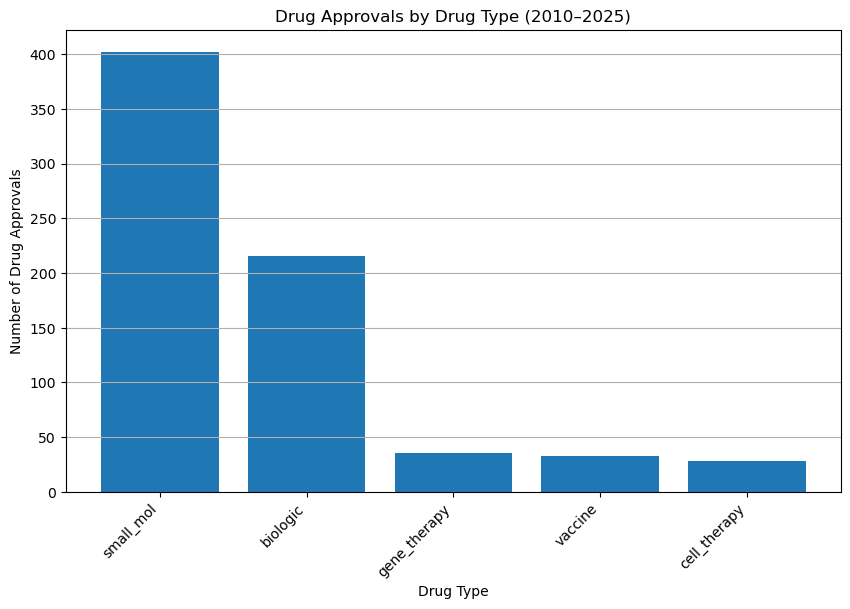

In [8]:
approvals_by_drug_type = (
    drug_approvals_main
    .groupby("drug_type")
    .size()
    .reset_index(name="approval_count")
    .sort_values("approval_count", ascending=False)
    .reset_index(drop=True)
)

display(approvals_by_drug_type)

plt.figure(figsize=(10, 6))
plt.bar(
    approvals_by_drug_type["drug_type"],
    approvals_by_drug_type["approval_count"]
)

plt.title("Drug Approvals by Drug Type (2010–2025)")
plt.xlabel("Drug Type")
plt.ylabel("Number of Drug Approvals")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Drug Type Approval Observation

Drug approvals between 2010 and 2025 were dominated by small molecules and biologics.

Small molecules accounted for the largest number of approvals, followed by biologics. Gene therapies, vaccines, and cell therapies had much lower approval counts, but they remain strategically important because they represent more specialized and emerging innovation areas.

This suggests that traditional and biologic drug modalities still dominate approval volume, while advanced therapies appear more limited in count but potentially important for future innovation analysis.

## Step 12: Blockbuster and Mega-Blockbuster Share

This step calculates the share of approved drugs classified as blockbuster and mega-blockbuster based on estimated peak sales.

In [9]:
blockbuster_summary = pd.DataFrame({
    "metric": ["Blockbuster Share", "Mega-Blockbuster Share"],
    "count": [
        drug_approvals_main["is_blockbuster"].sum(),
        drug_approvals_main["is_mega_blockbuster"].sum()
    ],
    "share_pct": [
        drug_approvals_main["is_blockbuster"].mean() * 100,
        drug_approvals_main["is_mega_blockbuster"].mean() * 100
    ]
})

blockbuster_summary

,metric,count,share_pct
0,Blockbuster Share,152,21.258741
1,Mega-Blockbuster Share,41,5.734266


### Blockbuster Potential Observation

Between 2010 and 2025, approximately 21.3% of approved drugs were classified as blockbuster based on estimated peak sales, while approximately 5.7% were classified as mega-blockbusters.

This suggests that most approvals do not reach blockbuster-level commercial potential, but a meaningful minority of approved drugs may drive a disproportionate share of future revenue. Later analysis should compare blockbuster concentration across therapy areas and sponsor companies.

## Step 14: Estimated Peak Sales by Therapy Area

This step calculates total and average estimated peak sales by therapy area. It helps identify which therapy areas have the strongest commercial potential, not only the highest approval count.

,therapy_area,approval_count,total_peak_sales_usd_bn,avg_peak_sales_usd_bn,blockbuster_count,mega_blockbuster_count
0,oncology,272,227.09,0.834890,49,10
1,infectious,57,149.48,2.622456,16,7
2,rare_disease,68,93.56,1.375882,19,5
3,neurology,94,90.50,0.962766,22,4
4,metabolic,38,90.15,2.372368,11,5
5,immunology,66,80.45,1.218939,13,5
6,cardiovascular,49,58.48,1.193469,11,3
7,ophthalmology,11,15.85,1.440909,4,1
8,respiratory,20,15.62,0.781000,3,1
9,psychiatry,20,9.68,0.484000,2,0


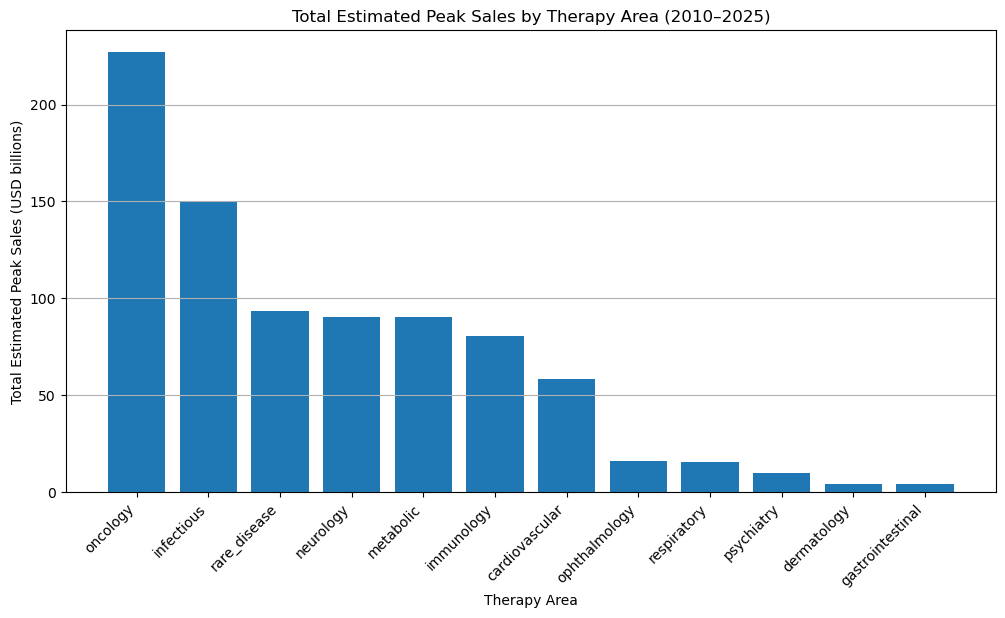

In [10]:
peak_sales_by_therapy_area = (
    drug_approvals_main
    .groupby("therapy_area")
    .agg(
        approval_count=("approval_id", "count"),
        total_peak_sales_usd_bn=("peak_sales_usd_bn_est", "sum"),
        avg_peak_sales_usd_bn=("peak_sales_usd_bn_est", "mean"),
        blockbuster_count=("is_blockbuster", "sum"),
        mega_blockbuster_count=("is_mega_blockbuster", "sum")
    )
    .sort_values("total_peak_sales_usd_bn", ascending=False)
    .reset_index()
)

display(peak_sales_by_therapy_area)

plt.figure(figsize=(12, 6))
plt.bar(
    peak_sales_by_therapy_area["therapy_area"],
    peak_sales_by_therapy_area["total_peak_sales_usd_bn"]
)

plt.title("Total Estimated Peak Sales by Therapy Area (2010–2025)")
plt.xlabel("Therapy Area")
plt.ylabel("Total Estimated Peak Sales (USD billions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Estimated Peak Sales by Therapy Area Observation

Oncology had the highest total estimated peak sales between 2010 and 2025, reinforcing its dominant role in both approval volume and commercial potential.

Infectious disease ranked second by total estimated peak sales, despite having fewer approvals than oncology. Rare disease, neurology, metabolic, and immunology also showed meaningful commercial potential.

This suggests that therapy area importance should not be evaluated only by approval count. Estimated peak sales provide an additional commercial lens and help identify areas where fewer approvals may still represent significant market value.

## Drug Approvals Interim Summary

The drug approvals analysis shows several important patterns:

- Drug approval activity fluctuated between 2010 and 2025, with stronger approval levels in later years.
- Oncology dominated approval activity by therapy area.
- Sponsor-level approval activity was more evenly distributed among leading companies.
- Small molecules and biologics dominated approval counts by drug type.
- Around 21% of approvals were classified as blockbuster drugs, while around 6% were classified as mega-blockbusters.
- Oncology also had the highest total estimated peak sales, suggesting strong alignment between approval concentration and commercial potential.

These findings suggest that pharmaceutical innovation activity is not evenly distributed across therapy areas. Oncology appears especially dominant both by approval volume and estimated commercial value.

# Clinical Trials Analysis

This section explores clinical trials between 2010 and 2025. The analysis focuses on trial activity over time, phase distribution, success rates, therapy area differences, outcomes, and estimated stock impact.

## Step 17: Preview Main Clinical Trials Dataset

This step previews the filtered clinical trials dataset for the 2010–2025 main analysis period. It helps confirm the available trial-level columns before analyzing trial activity and success patterns.

In [11]:
clinical_trials_main.head()

,trial_id,completion_date,year,sponsor,therapy_area,phase,enrollment_n,duration_months,outcome,is_success,is_failure,estimated_stock_impact_pct
0,NCT00000024,2010-01-05,2010,BioNTech,neurology,Phase 2,186,11,Met primary endpoint,1,0,6.0
1,NCT00000015,2010-02-15,2010,Pfizer,metabolic,Phase 2,181,29,Mixed results,0,0,-0.7
2,NCT00000013,2010-02-27,2010,GSK,oncology,Phase 2,115,13,Failed primary endpoint,0,1,-33.2
3,NCT00000022,2010-03-02,2010,Takeda,infectious,Phase 2,359,15,Met primary endpoint,1,0,12.4
4,NCT00000019,2010-04-09,2010,Novo Nordisk,oncology,Phase 3,840,42,Failed primary endpoint,0,1,-14.7


## Step 18: Clinical Trials by Year

This step calculates and visualizes the number of completed clinical trials by year between 2010 and 2025.

,year,trial_count
0,2010,34
1,2011,42
2,2012,41
3,2013,42
4,2014,32
5,2015,36
6,2016,31
7,2017,41
8,2018,36
9,2019,33


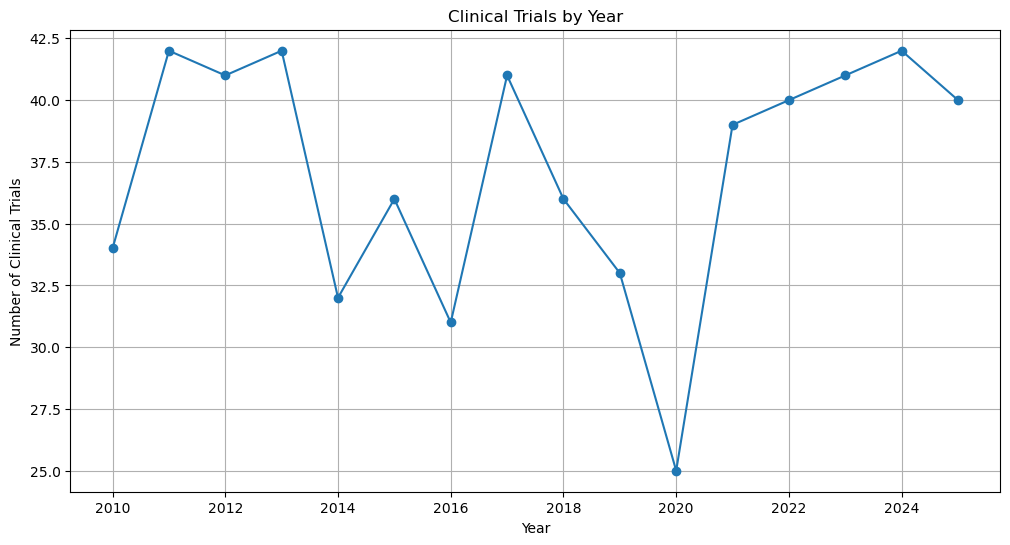

In [12]:
trials_by_year = (
    clinical_trials_main
    .groupby("year")
    .size()
    .reset_index(name="trial_count")
)

display(trials_by_year)

plt.figure(figsize=(12, 6))
plt.plot(
    trials_by_year["year"],
    trials_by_year["trial_count"],
    marker="o"
)

plt.title("Clinical Trials by Year")
plt.xlabel("Year")
plt.ylabel("Number of Clinical Trials")
plt.grid(True)
plt.show()

## Step 19: Clinical Trials by Phase

This step calculates and visualizes the distribution of clinical trials by phase. It helps identify whether the dataset is concentrated in earlier or later-stage trials.

,phase,trial_count
0,Phase 3,324
1,Phase 2,271


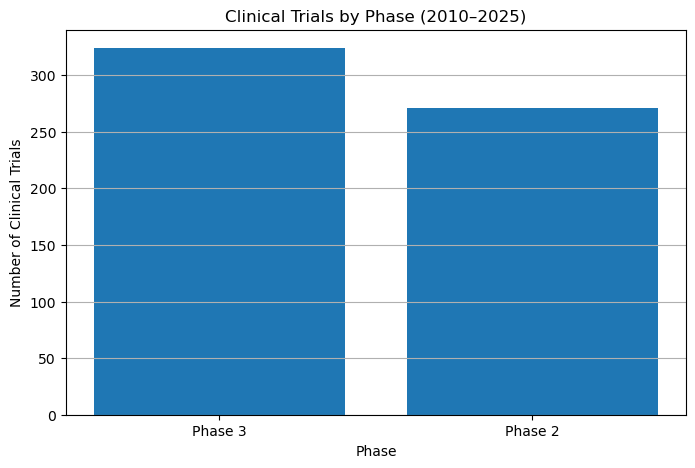

In [13]:
trials_by_phase = (
    clinical_trials_main
    .groupby("phase")
    .size()
    .reset_index(name="trial_count")
    .sort_values("trial_count", ascending=False)
    .reset_index(drop=True)
)

display(trials_by_phase)

plt.figure(figsize=(8, 5))
plt.bar(
    trials_by_phase["phase"],
    trials_by_phase["trial_count"]
)

plt.title("Clinical Trials by Phase (2010–2025)")
plt.xlabel("Phase")
plt.ylabel("Number of Clinical Trials")
plt.grid(axis="y")
plt.show()

## Step 20: Clinical Trial Success Rate by Phase

This step calculates the success rate and failure rate by clinical trial phase. It helps compare whether Phase 2 and Phase 3 trials differ in development risk and outcome performance.

,phase,trial_count,successful_trials,failed_trials,success_rate_pct,failure_rate_pct,avg_stock_impact_pct
0,Phase 2,271,165,58,60.885609,21.402214,1.198893
1,Phase 3,324,143,137,44.135802,42.283951,-2.808951


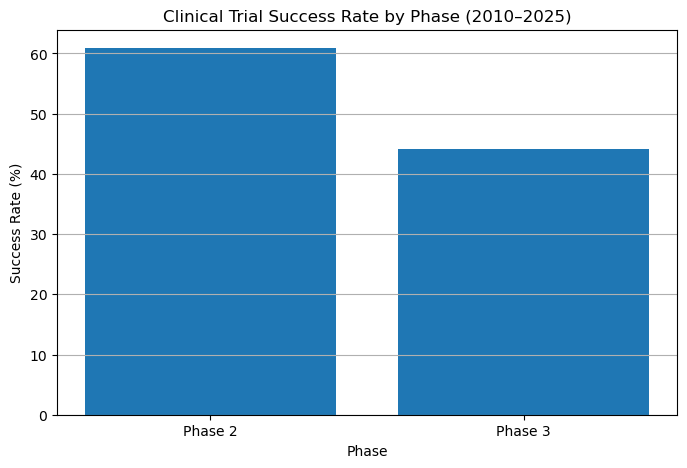

In [14]:
success_by_phase = (
    clinical_trials_main
    .groupby("phase")
    .agg(
        trial_count=("trial_id", "count"),
        successful_trials=("is_success", "sum"),
        failed_trials=("is_failure", "sum"),
        success_rate_pct=("is_success", "mean"),
        failure_rate_pct=("is_failure", "mean"),
        avg_stock_impact_pct=("estimated_stock_impact_pct", "mean")
    )
    .reset_index()
)

success_by_phase["success_rate_pct"] = success_by_phase["success_rate_pct"] * 100
success_by_phase["failure_rate_pct"] = success_by_phase["failure_rate_pct"] * 100

success_by_phase = success_by_phase.sort_values(
    "success_rate_pct",
    ascending=False
).reset_index(drop=True)

display(success_by_phase)

plt.figure(figsize=(8, 5))
plt.bar(
    success_by_phase["phase"],
    success_by_phase["success_rate_pct"]
)

plt.title("Clinical Trial Success Rate by Phase (2010–2025)")
plt.xlabel("Phase")
plt.ylabel("Success Rate (%)")
plt.grid(axis="y")
plt.show()

## Step 21: Clinical Trial Success Rate by Therapy Area

This step calculates trial success rates by therapy area. It helps identify which therapeutic fields showed stronger or weaker clinical development outcomes between 2010 and 2025.

,therapy_area,trial_count,successful_trials,failed_trials,success_rate_pct,failure_rate_pct,avg_stock_impact_pct,avg_enrollment,avg_duration_months
0,cardiovascular,67,54,9,80.597015,13.432836,3.177612,786.432836,27.343284
1,respiratory,23,18,4,78.260870,17.391304,5.421739,575.565217,23.956522
2,infectious,58,43,5,74.137931,8.620690,5.034483,901.172414,28.465517
3,gastrointestinal,23,15,5,65.217391,21.739130,2.704348,514.173913,28.478261
4,metabolic,47,29,5,61.702128,10.638298,3.210638,796.106383,27.680851
5,rare_disease,45,24,17,53.333333,37.777778,-0.513333,757.288889,26.288889
6,immunology,74,39,20,52.702703,27.027027,-0.279730,682.851351,26.770270
7,psychiatry,17,7,10,41.176471,58.823529,-3.717647,922.117647,29.470588
8,oncology,179,62,82,34.636872,45.810056,-4.849721,866.608939,28.664804
9,neurology,62,17,38,27.419355,61.290323,-7.303226,778.580645,26.274194


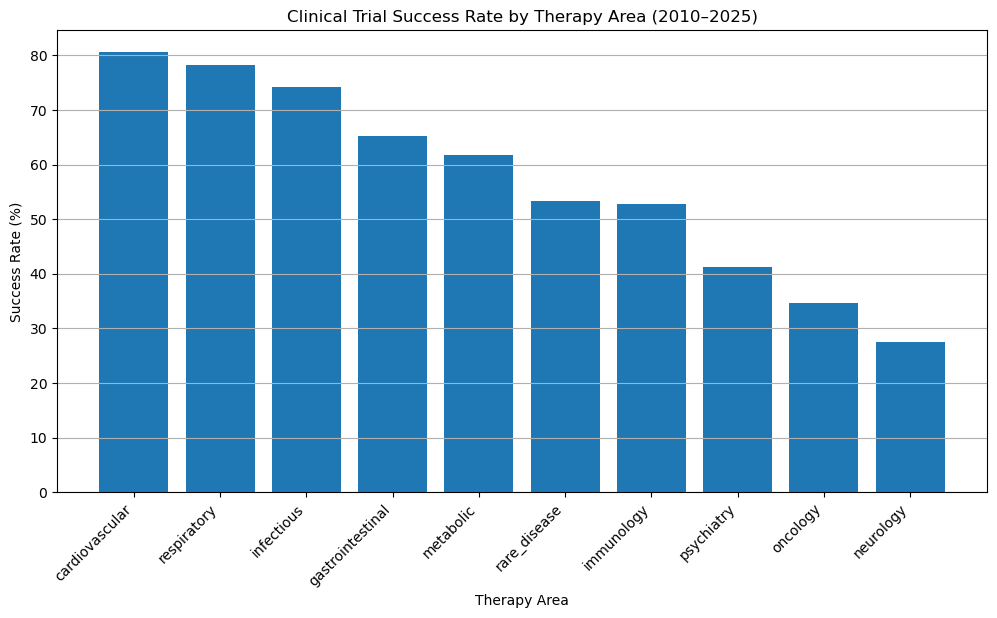

In [15]:
success_by_therapy_area = (
    clinical_trials_main
    .groupby("therapy_area")
    .agg(
        trial_count=("trial_id", "count"),
        successful_trials=("is_success", "sum"),
        failed_trials=("is_failure", "sum"),
        success_rate_pct=("is_success", "mean"),
        failure_rate_pct=("is_failure", "mean"),
        avg_stock_impact_pct=("estimated_stock_impact_pct", "mean"),
        avg_enrollment=("enrollment_n", "mean"),
        avg_duration_months=("duration_months", "mean")
    )
    .reset_index()
)

success_by_therapy_area["success_rate_pct"] = success_by_therapy_area["success_rate_pct"] * 100
success_by_therapy_area["failure_rate_pct"] = success_by_therapy_area["failure_rate_pct"] * 100

success_by_therapy_area = success_by_therapy_area.sort_values(
    "success_rate_pct",
    ascending=False
).reset_index(drop=True)

display(success_by_therapy_area)

plt.figure(figsize=(12, 6))
plt.bar(
    success_by_therapy_area["therapy_area"],
    success_by_therapy_area["success_rate_pct"]
)

plt.title("Clinical Trial Success Rate by Therapy Area (2010–2025)")
plt.xlabel("Therapy Area")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Therapy Area Trial Success Observation

Clinical trial success rates varied strongly by therapy area between 2010 and 2025.

Cardiovascular, respiratory, and infectious disease trials showed the highest success rates, while oncology and neurology showed much lower success rates.

This is especially important because oncology dominated drug approvals and estimated peak sales, but showed relatively low clinical trial success. This suggests that oncology may combine high commercial potential with high clinical development risk.

## Step 23: Trial Outcomes and Average Stock Impact

This step summarizes clinical trial outcomes and compares average estimated stock impact by outcome type.

,outcome,trial_count,avg_stock_impact_pct,success_count,failure_count
0,Met primary endpoint,308,7.950649,308,0
1,Failed primary endpoint,195,-13.747179,0,195
2,Mixed results,92,-3.840217,0,0


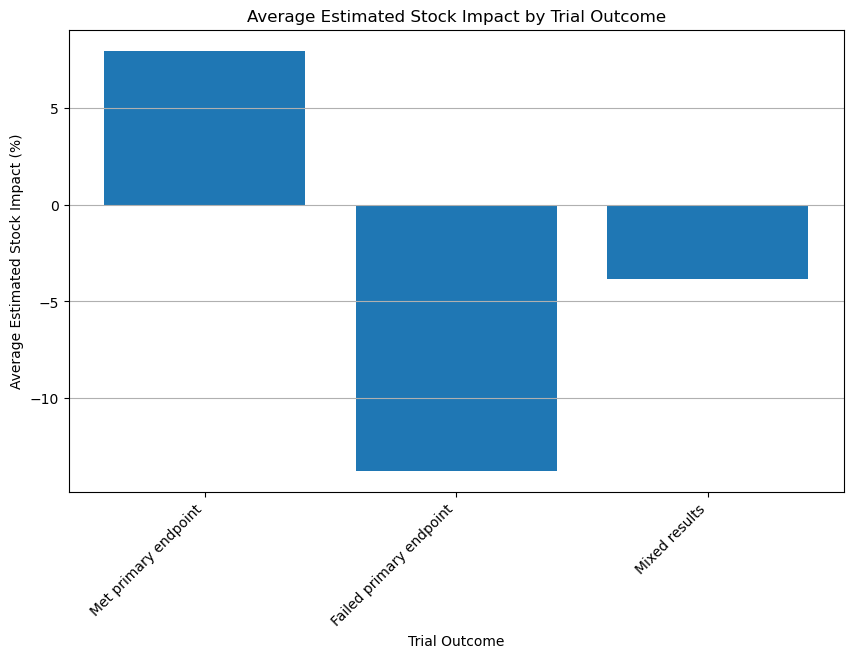

In [16]:
outcome_summary = (
    clinical_trials_main
    .groupby("outcome")
    .agg(
        trial_count=("trial_id", "count"),
        avg_stock_impact_pct=("estimated_stock_impact_pct", "mean"),
        success_count=("is_success", "sum"),
        failure_count=("is_failure", "sum")
    )
    .sort_values("trial_count", ascending=False)
    .reset_index()
)

display(outcome_summary)

plt.figure(figsize=(10, 6))
plt.bar(
    outcome_summary["outcome"],
    outcome_summary["avg_stock_impact_pct"]
)

plt.title("Average Estimated Stock Impact by Trial Outcome")
plt.xlabel("Trial Outcome")
plt.ylabel("Average Estimated Stock Impact (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

## Clinical Trials Interim Summary

The clinical trials analysis shows several important patterns:

- Clinical trial activity fluctuated between 2010 and 2025, with a visible decline in 2020 and recovery afterward.
- The dataset contains Phase 2 and Phase 3 trials, with slightly more Phase 3 trials.
- Phase 2 trials showed a higher success rate than Phase 3 trials in this dataset.
- Phase 3 trials had a higher failure rate and a more negative average estimated stock impact.
- Cardiovascular, respiratory, and infectious disease trials showed the highest success rates.
- Oncology and neurology showed lower clinical trial success rates, despite oncology being dominant in drug approvals and estimated peak sales.
- Trial outcomes were strongly associated with estimated stock impact: successful trials had positive average impact, failed trials had strongly negative impact, and mixed results were moderately negative.

These findings suggest that clinical development risk varies significantly by phase, therapy area, and trial outcome. Oncology appears especially important because it combines high approval volume and commercial potential with relatively low clinical trial success rates.

# Notebook Summary and Next Steps

This notebook completed the exploratory analysis of drug approvals and clinical trials for the 2010–2025 main analysis period.

Key drug approval findings:

- Drug approvals fluctuated over time, with stronger approval activity in later years.
- Oncology dominated approval activity by therapy area.
- Sponsor-level approval activity was more distributed across leading companies.
- Small molecules and biologics dominated approval volume.
- Approximately 21% of approvals were classified as blockbuster drugs, while approximately 6% were classified as mega-blockbusters.
- Oncology also had the highest total estimated peak sales, suggesting strong commercial concentration.

Key clinical trial findings:

- Clinical trial activity fluctuated over time, with a visible dip in 2020 and recovery afterward.
- Phase 2 trials showed a higher success rate than Phase 3 trials in this dataset.
- Phase 3 trials had a higher failure rate and more negative average estimated stock impact.
- Cardiovascular, respiratory, and infectious disease trials showed the strongest success rates.
- Oncology and neurology showed lower clinical trial success rates.
- Failed primary endpoint outcomes were associated with strongly negative estimated stock impact.

Overall interpretation:

Drug approvals and clinical trial outcomes show that pharmaceutical innovation is not evenly distributed across therapy areas. Oncology appears highly concentrated in approval volume and commercial potential, but it also shows relatively low clinical trial success, suggesting a high-risk, high-reward innovation profile.

The next notebook will explore biotech funding and disease burden. This will help compare commercial innovation activity with investment trends and real-world healthcare need.